# Analisis Time Series Univariat

#### 1.Import Library

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


2.Ambil data saham bitcoin

[*********************100%***********************]  1 of 1 completed


Price           Close
Ticker            BTC
Date                 
2024-07-31  28.950001
2024-08-01  28.100000
2024-08-02  27.799999
2024-08-05  23.750000
2024-08-06  25.250000


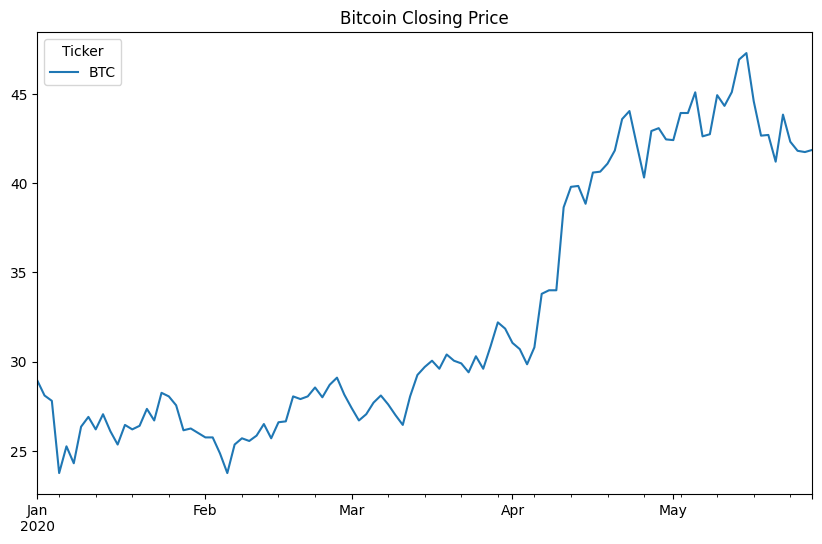

In [13]:
data = yf.download('BTC', start='2020-01-01', end='2025-01-01')
data = data[['Close']] 
print(data.head())


data.index = pd.date_range(start='2020-01-01', periods=len(data), freq='B')  


data['Close'].plot(figsize=(10,6), title='Bitcoin Closing Price')
plt.show()

In [4]:
# Cek apakah ada missing value
missing_values = data.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

# Cek apakah ada nilai NaN
nan_values = data.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)

Jumlah missing values per kolom:
Price  Ticker
Close  BTC       0
dtype: int64
Jumlah nilai NaN per kolom:
Price  Ticker
Close  BTC       0
dtype: int64


3.Cek asumsi stasionaritas dengan ADF

In [5]:
from statsmodels.tsa.stattools import adfuller


result = adfuller(data['Close'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])


if result[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


ADF Statistic: -0.471307
p-value: 0.897495
Data tidak stasioner, lakukan differencing.


5.Melalkukan differencing

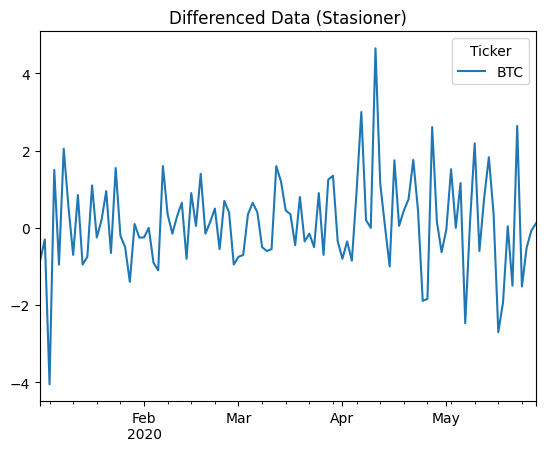

p-value after differencing: 0.000000
Data stasioner, lanjutkan analisis.


In [6]:

data_diff = data['Close'].diff().dropna()
data_diff.plot(title="Differenced Data (Stasioner)")
plt.show()


result_diff = adfuller(data_diff)
print('p-value after differencing: %f' % result_diff[1])


if result_diff[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


6.cek ACF dan PACF


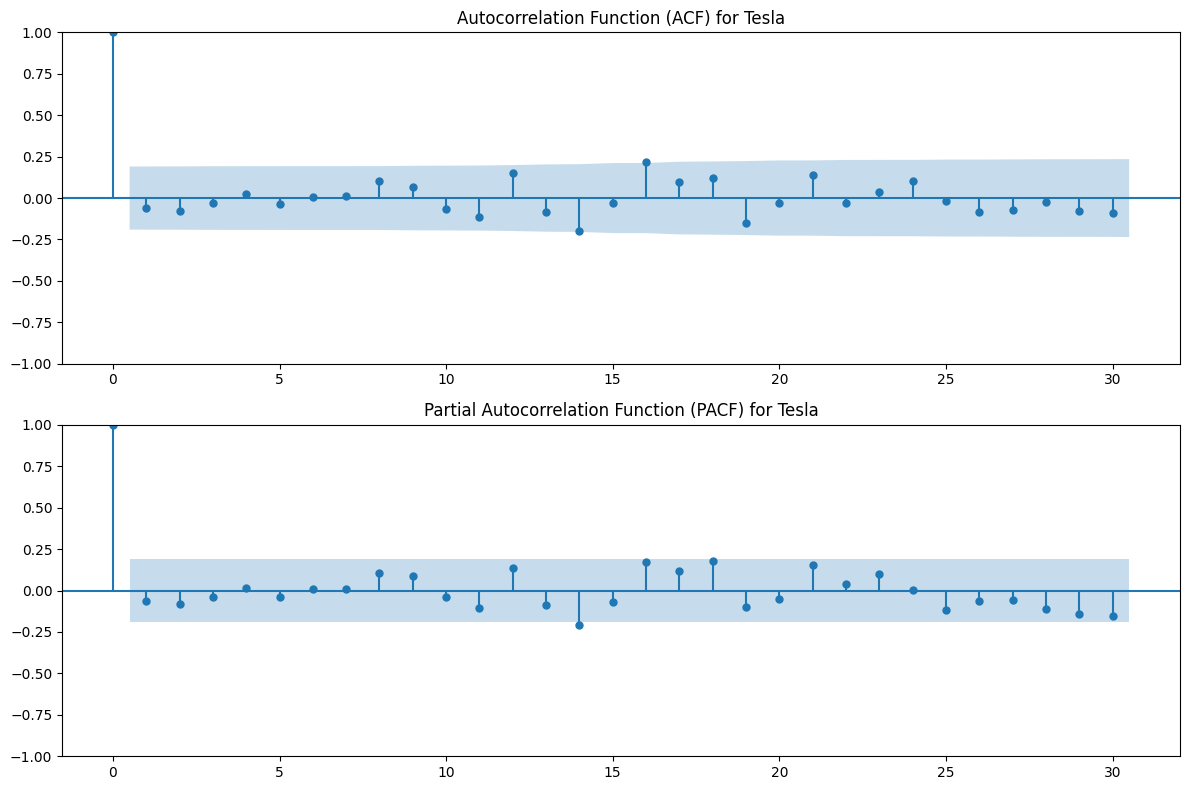

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# ACF untuk menentukan q
plot_acf(data_diff, lags=30, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) for Tesla')

# PACF untuk menentukan p
plot_pacf(data_diff, lags=30, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) for Tesla')

plt.tight_layout()
plt.show()

7.Membangun model

In [9]:
from statsmodels.tsa.arima.model import ARIMA


model = ARIMA(data, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Close_BTC   No. Observations:                  107
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -171.051
Date:                Tue, 14 Apr 2026   AIC                            348.103
Time:                        15:29:46   BIC                            356.093
Sample:                    01-01-2020   HQIC                           351.341
                         - 05-28-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4093      0.934      0.438      0.661      -1.420       2.239
ma.L1         -0.4765      0.892     -0.534      0.593      -2.224       1.271
sigma2         1.4762      0.145     10.195      0.0

8.peramalan data

2020-05-29    41.877388
2020-06-01    41.880412
2020-06-02    41.881650
2020-06-03    41.882156
2020-06-04    41.882364
2020-06-05    41.882448
2020-06-08    41.882483
2020-06-09    41.882497
2020-06-10    41.882503
2020-06-11    41.882506
2020-06-12    41.882507
2020-06-15    41.882507
2020-06-16    41.882507
2020-06-17    41.882507
2020-06-18    41.882507
2020-06-19    41.882507
2020-06-22    41.882507
2020-06-23    41.882507
2020-06-24    41.882507
2020-06-25    41.882507
Freq: B, Name: predicted_mean, dtype: float64


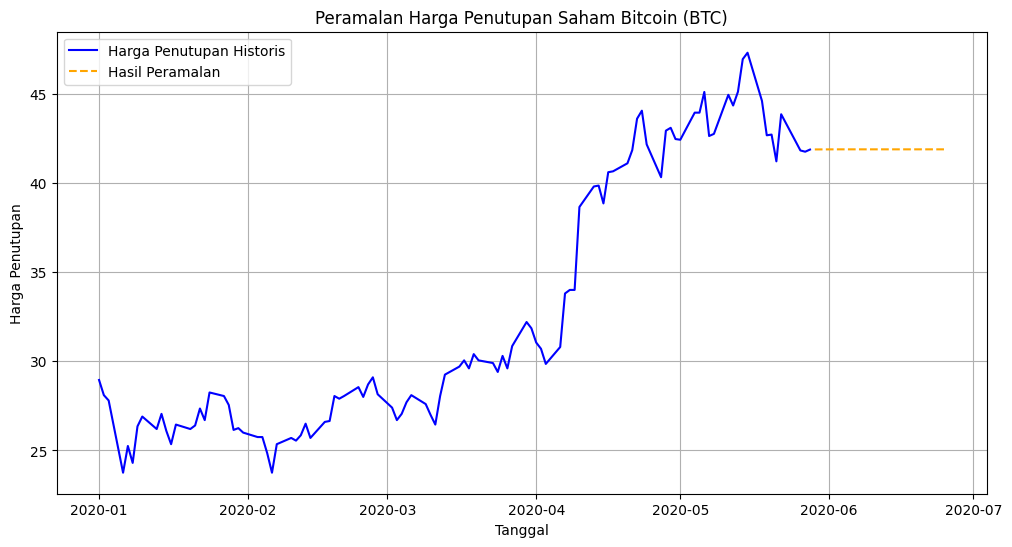

In [12]:

n_steps = 20
forecast = model_fit.forecast(steps=n_steps)
print(forecast)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Harga Penutupan Historis', color='blue')


forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=n_steps, freq='B')


plt.plot(forecast_index, forecast, label='Hasil Peramalan', color='orange', linestyle='--')


plt.title('Peramalan Harga Penutupan Saham Bitcoin (BTC)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.grid()
plt.show()

---
# Time Series Multivariate 

[*********************100%***********************]  2 of 2 completed


Ticker          BTC-USD     ETH-USD
Date                               
2020-01-01  7200.174316  130.802002
2020-01-02  6985.470215  127.410179
2020-01-03  7344.884277  134.171707
2020-01-04  7410.656738  135.069366
2020-01-05  7411.317383  136.276779

BTC
ADF Statistic: -1.448566893608795
p-value: 0.558784024987776

ETH
ADF Statistic: -1.5966433056278961
p-value: 0.48527944836973613

Differencing dilakukan untuk semua variabel.


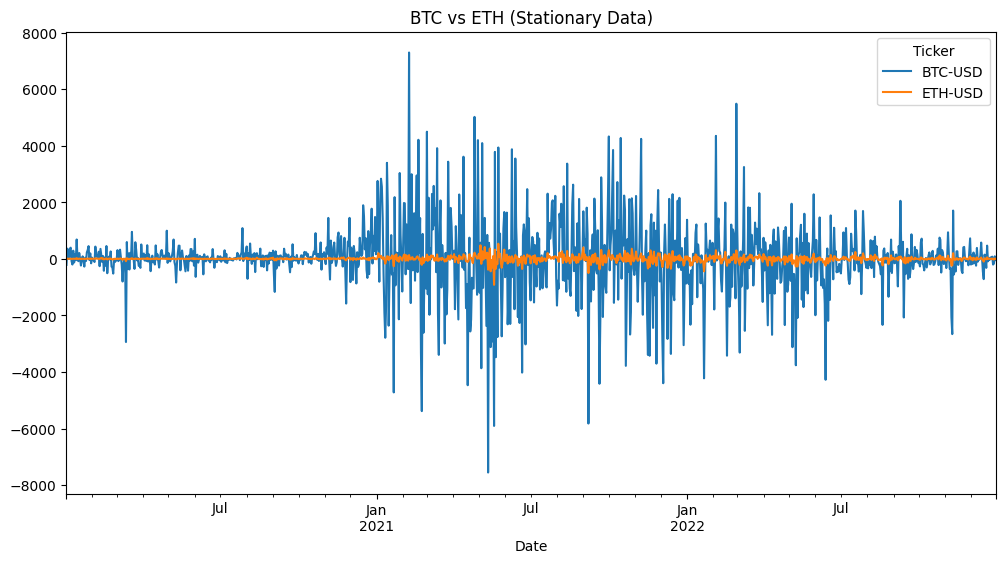

In [16]:
# Import libraries 
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt


tickers = ['BTC-USD', 'ETH-USD']


data = yf.download(tickers, start='2020-01-01', end='2023-01-01')


data_combined = data['Close'].copy()

print(data_combined.head())

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'\n{name}')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    return result[1] < 0.05


is_stationary_btc = check_stationarity(data_combined['BTC-USD'], 'BTC')
is_stationary_eth = check_stationarity(data_combined['ETH-USD'], 'ETH')


if not (is_stationary_btc and is_stationary_eth):
    data_combined = data_combined.diff().dropna()
    print("\nDifferencing dilakukan untuk semua variabel.")


data_combined.plot(figsize=(12,6), title='BTC vs ETH (Stationary Data)')
plt.show()

In [17]:
from statsmodels.tsa.api import VAR


model = VAR(data_combined)
lag_order = model.select_order(maxlags=15)  
print(lag_order.summary())


optimal_lag = lag_order.aic  
var_model = model.fit(optimal_lag)


print(var_model.summary())

c:\Users\Michael Zidane\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        22.64      22.65*   6.788e+09      22.64*
1        22.63       22.66   6.764e+09       22.65
2        22.63       22.68   6.748e+09       22.65
3        22.63       22.70   6.759e+09       22.66
4        22.64       22.72   6.770e+09       22.67
5        22.63       22.73   6.699e+09       22.66
6        22.62       22.74   6.638e+09       22.66
7       22.61*       22.75  6.599e+09*       22.66
8        22.62       22.77   6.638e+09       22.68
9        22.61       22.79   6.603e+09       22.68
10       22.62       22.81   6.639e+09       22.69
11       22.62       22.83   6.645e+09       22.70
12       22.62       22.85   6.643e+09       22.70
13       22.62       22.87   6.676e+09       22.72
14       22.62       22.89   6.676e+09       22.72
15       22.63       22.91   6.704e+09       22.73
-------------------------------